# PHÂN TÍCH VÀ CHUẨN ĐOÁN BỆNH TIM MẠCH


## 1. KHẢO SÁT CẤU TRÚC VÀ ĐỌC DỮ LIỆU BAN ĐẦU
Bước này tiến hành nạp tập dữ liệu dịch tễ học Framingham thô từ tệp CSV vào hệ thống, sau đó thực hiện kiểm tra sơ bộ kích thước dữ liệu (số dòng, số cột), xem trước các bản ghi mẫu, kiểm tra kiểu dữ liệu hệ thống và rà soát các hàng dữ liệu bị trùng lặp.

In [1]:
import pandas as pd
import numpy as np

# 1. Đọc bộ dữ liệu Framingham Heart Study từ file csv
df = pd.read_csv('framingham.csv')

# 2. Kiểm tra kích thước tổng quan (Số dòng, số cột)
print(f"Kích thước bộ dữ liệu thô: {df.shape[0]} dòng, {df.shape[1]} cột.\n")

# 3. Hiển thị 5 bản ghi đầu tiên để quan sát cấu trúc bảng mẫu
print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head())

# 4. Kiểm tra kiểu dữ liệu hệ thống và tổng quan số lượng bản ghi không trống
print("\n--- THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU ---")
df.info()

# 5. Kiểm tra và thống kê số lượng hàng dữ liệu bị trùng lặp
duplicate_count = df.duplicated().sum()
print(f"\nSố lượng bản ghi trùng lặp trong hệ thống: {duplicate_count}")

Kích thước bộ dữ liệu thô: 4240 dòng, 16 cột.

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0



--- THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64

## 2. KIỂM TRA VÀ XỬ LÝ GIÁ TRỊ KHUYẾT THIẾU (MISSING VALUES)
Thống kê chính xác số lượng và tỷ lệ phần trăm các ô bị trống trên từng thuộc tính lâm sàng. Tiến hành nội suy điền khuyết thiếu bằng phương pháp y sinh an toàn: Điền bằng **Yếu vị (Mode)** cho thuộc tính định tính (`BPMeds`, `education`) và điền bằng **Trung vị (Median)** cho các thuộc tính định lượng liên tục để triệt tiêu ảnh hưởng của các giá trị ngoại lệ cực đoan (Outliers).

In [2]:
# 1. Thống kê số lượng và tỷ lệ % giá trị khuyết thiếu trên từng cột thuộc tính
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Số lượng thiếu', 'Tỷ lệ (%)'])
print("--- THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU BAN ĐẦU ---")
display(missing_table[missing_table['Số lượng thiếu'] > 0])

# 2. Xử lý điền khuyết (Imputation) bảo toàn phân phối
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])
df['education'] = df['education'].fillna(df['education'].mode()[0])

continuous_missing = ['totChol', 'glucose', 'BMI', 'heartRate']
for col in continuous_missing:
    df[col] = df[col].fillna(df[col].median())

print("\nKiểm tra lại tổng số lượng giá trị khuyết thiếu sau khi xử lý:", df.isnull().sum().sum())

--- THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU BAN ĐẦU ---


,Số lượng thiếu,Tỷ lệ (%)
education,105,2.476415
cigsPerDay,29,0.683962
BPMeds,53,1.250000
totChol,50,1.179245
BMI,19,0.448113
heartRate,1,0.023585
glucose,388,9.150943



Kiểm tra lại tổng số lượng giá trị khuyết thiếu sau khi xử lý: 29


## 3. ĐỒNG BỘ LOGIC HÀNH VI HÚT THUỐC
Tiến hành chuẩn hóa logic dữ liệu hành vi ngoại sinh: Nếu bệnh nhân có trạng thái không hút thuốc (`currentSmoker = 0`) nhưng số điếu thuốc khuyết thiếu hoặc sai lệch thì ép về 0. Nếu bệnh nhân có hút thuốc (`currentSmoker = 1`) nhưng bị trống trường số lượng điếu, tiến hành điền bằng giá trị trung vị của riêng nhóm những người có hút thuốc hiện tại.

In [4]:
# Đồng bộ hóa logic giữa thuộc tính currentSmoker và cigsPerDay
df.loc[df['currentSmoker'] == 0, 'cigsPerDay'] = 0

median_cigs = df[df['currentSmoker'] == 1]['cigsPerDay'].median()
df['cigsPerDay'] = df['cigsPerDay'].fillna(median_cigs)

print("Thống kê mô tả cột số điếu thuốc (cigsPerDay) sau khi đồng bộ logic:")
print(df['cigsPerDay'].describe())

Thống kê mô tả cột số điếu thuốc (cigsPerDay) sau khi đồng bộ logic:
count    4240.000000
mean        9.081132
std        11.916119
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max        70.000000
Name: cigsPerDay, dtype: float64


## 4.TÍNH TOÁN CHỈ SỐ MAP KHỬ ĐA CỘNG TUYẾN
Bộ đôi chỉ số huyết áp tâm thu (`sysBP`) và huyết áp tâm trương (`diaBP`) mang tính trùng lặp thông tin tuyến tính rất mạnh, dễ gây ra hiện tượng đa cộng tuyến làm lệch khoảng cách hình học. Ô code này thực hiện gộp hai thuộc tính trên thành một chỉ số y sinh duy nhất là **Áp lực động mạch trung bình (MAP)** và tiến hành loại bỏ hoàn toàn hai thuộc tính thô ban đầu.

In [5]:
# Áp dụng công thức y sinh tiêu chuẩn: MAP = diaBP + (sysBP - diaBP) / 3
df['MAP'] = df['diaBP'] + (df['sysBP'] - df['diaBP']) / 3

# Loại bỏ hai cột huyết áp thô ban đầu để tối ưu hóa không gian đặc trưng
df = df.drop(columns=['sysBP', 'diaBP'])

print("Danh sách các thuộc tính tối ưu được giữ lại trong mô hình:\n", df.columns.tolist())

Danh sách các thuộc tính tối ưu được giữ lại trong mô hình:
 ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'BMI', 'heartRate', 'glucose', 'TenYearCHD', 'MAP']


## 5. THIẾT LẬP ĐỊNH DẠNG BIẾN DANH MỤC (CATEGORICAL FEATURES)
Ép kiểu dữ liệu hệ thống cho các thuộc tính định tính nhị phân hoặc phân lớp từ dạng số (`int64` / `float64`) sang kiểu dữ liệu danh mục chuyên dụng (`category`) của thư viện Pandas nhằm tối ưu hóa không gian lưu trữ bộ nhớ RAM và đồng bộ ngữ nghĩa cho thuật toán học máy.

In [6]:
# Định danh danh sách các biến phân loại danh mục
categorical_features = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

# Thực hiện ép kiểu cấu trúc dữ liệu sang 'category'
for column in categorical_features:
    df[column] = df[column].astype('category')

print("--- KIỂM TRA LẠI KIỂU DỮ LIỆU HỆ THỐNG ĐÃ MÃ HÓA CHUẨN ---")
print(df.dtypes)

--- KIỂM TRA LẠI KIỂU DỮ LIỆU HỆ THỐNG ĐÃ MÃ HÓA CHUẨN ---
male               category
age                   int64
education          category
currentSmoker      category
cigsPerDay          float64
BPMeds             category
prevalentStroke    category
prevalentHyp       category
diabetes           category
totChol             float64
BMI                 float64
heartRate           float64
glucose             float64
TenYearCHD            int64
MAP                 float64
dtype: object


## 6. CHUẨN HÓA THANG ĐO HÌNH HỌC ĐA CHIỀU (Z-SCORE)
Các thuộc tính định lượng liên tục ban đầu có quy mô đơn vị đo lường chênh lệch rất lớn (ví dụ: `totChol` lên tới hàng trăm mg/dL, trong khi `age` chỉ ở hàng chục năm). Điều này làm sai lệch nghiêm trọng khoảng cách Euclid của mô hình K-Means. Ô code này áp dụng công cụ `StandardScaler` để đưa toàn bộ thuộc tính liên tục về cùng phân phối chuẩn có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1.

In [7]:
from sklearn.preprocessing import StandardScaler

# Định danh các đặc trưng định lượng liên tục phục vụ tính toán khoảng cách
continuous_features = ['age', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose', 'MAP']
df_scaled = df.copy()

# Khởi tạo bộ lọc StandardScaler
scaler = StandardScaler()
df_scaled[continuous_features] = scaler.fit_transform(df[continuous_features])

print("--- MA TRẬN ĐẶC TRƯNG ĐỊNH LƯỢNG SAU KHI CHUẨN HÓA Z-SCORE ---")
display(df_scaled[continuous_features].describe().round(4))

--- MA TRẬN ĐẶC TRƯNG ĐỊNH LƯỢNG SAU KHI CHUẨN HÓA Z-SCORE ---


,age,cigsPerDay,totChol,BMI,heartRate,glucose,MAP
count,4240.0000,4240.0000,4240.0000,4240.0000,4240.0000,4240.0000,4240.0000
mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001
min,-2.0509,-0.7622,-2.9255,-2.5205,-2.6516,-1.8200,-2.5551
25%,-0.8843,-0.7622,-0.6919,-0.6686,-0.6553,-0.4200,-0.6847
50%,-0.0677,-0.7622,-0.0602,-0.0980,-0.0731,-0.1575,-0.1420
75%,0.7489,0.9164,0.5715,0.5487,0.5923,0.1487,0.5392
max,2.3822,5.1129,10.3632,7.6164,5.5830,13.6672,6.1620


## 7. GIẢI QUYẾT CÁC CÂU HỎI KHAI PHÁ VÀ DỰ ĐOÁN (EDA & PREDICTION)

### Câu hỏi 1: Độ tuổi nào có tỷ lệ nguy cơ mắc bệnh tim mạch cao nhất?
Thực hiện chia nhỏ biến liên tục Tuổi tác thành 4 nhóm khoảng thập kỷ cố định từ 30 đến 70 tuổi. Tính toán tỷ lệ phần trăm xuất hiện rủi ro mạch vành thực tế trên từng nhóm để tìm ra xu hướng biến thiên bệnh lý và vẽ biểu đồ cột trực quan hóa (đã cấu hình `hue` và `legend` chuẩn).

--- BẢNG SỐ LIỆU THỰC NGHIỆM THEO NHÓM TUỔI ---


,age_group,Tỷ lệ nguy cơ (%)
0,30-39 tuổi,4.136691
1,40-49 tuổi,10.054184
2,50-59 tuổi,19.729932
3,60-70 tuổi,27.681159


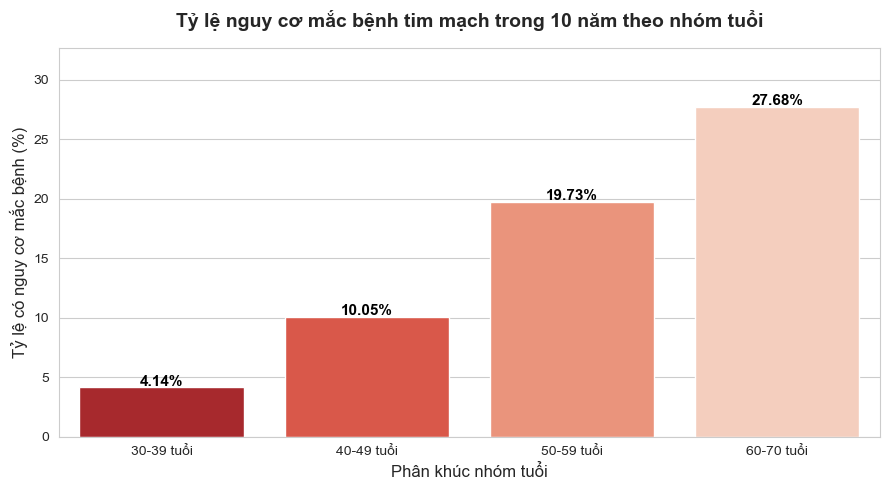

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Phân khoảng tuổi (Binning) thành các nhóm sinh học
bins = [30, 40, 50, 60, 71]
labels = ['30-39 tuổi', '40-49 tuổi', '50-59 tuổi', '60-70 tuổi']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Tính tỷ lệ % ca bệnh thực tế (TenYearCHD = 1) theo từng nhóm
age_stats = df.groupby('age_group', observed=False)['TenYearCHD'].mean() * 100
age_stats = age_stats.reset_index(name='Tỷ lệ nguy cơ (%)')

print("--- BẢNG SỐ LIỆU THỰC NGHIỆM THEO NHÓM TUỔI ---")
display(age_stats)

# Vẽ biểu đồ cột chữ lớn
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")
ax = sns.barplot(data=age_stats, x='age_group', y='Tỷ lệ nguy cơ (%)', hue='age_group', palette='Reds_r', legend=False)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=11, color='black', fontweight='bold')

plt.title('Tỷ lệ nguy cơ mắc bệnh tim mạch trong 10 năm theo nhóm tuổi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Phân khúc nhóm tuổi', fontsize=12)
plt.ylabel('Tỷ lệ có nguy cơ mắc bệnh (%)', fontsize=12)
plt.ylim(0, age_stats['Tỷ lệ nguy cơ (%)'].max() + 5)
plt.tight_layout()
plt.show()

### Câu hỏi 2: Giới tính nào có tỷ lệ nguy cơ mắc bệnh tim mạch cao hơn?
Thực hiện gom nhóm dữ liệu theo giới tính sinh học (0: Nữ giới, 1: Nam giới) để bóc tách và so sánh trực diện tỷ lệ phần trăm nguy cơ mắc bệnh tim mạch trong vòng 10 năm tới.

--- BẢNG SỐ LIỆU THỰC NGHIỆM THEO GIỚI TÍNH ---


,gender_label,Tỷ lệ nguy cơ (%)
0,Nữ giới,12.438017
1,Nam giới,18.846154


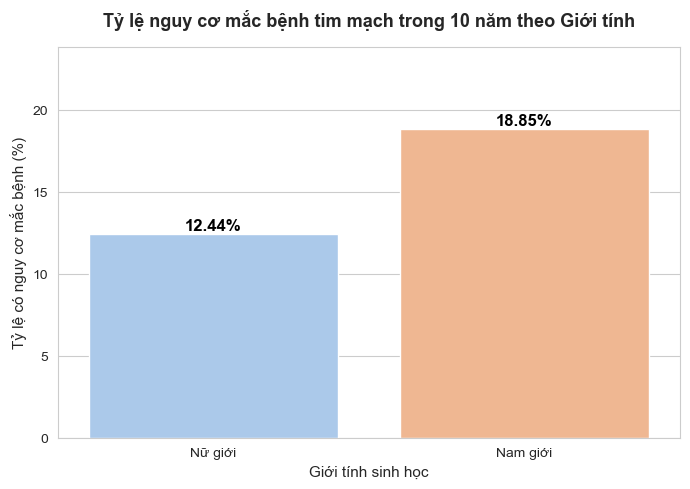

In [9]:
df_gender = df.copy()
df_gender['gender_label'] = df_gender['male'].map({0: 'Nữ giới', 1: 'Nam giới'})

# Tính toán tỷ lệ phần trăm rủi ro theo giới tính
gender_stats = df_gender.groupby('gender_label', observed=False)['TenYearCHD'].mean() * 100
gender_stats = gender_stats.reset_index(name='Tỷ lệ nguy cơ (%)')

print("--- BẢNG SỐ LIỆU THỰC NGHIỆM THEO GIỚI TÍNH ---")
display(gender_stats)

plt.figure(figsize=(7, 5))
sns.set_style("whitegrid")
ax = sns.barplot(data=gender_stats, x='gender_label', y='Tỷ lệ nguy cơ (%)', hue='gender_label', palette='pastel', legend=False)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=12, color='black', fontweight='bold')

plt.title('Tỷ lệ nguy cơ mắc bệnh tim mạch trong 10 năm theo Giới tính', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Giới tính sinh học', fontsize=11)
plt.ylabel('Tỷ lệ có nguy cơ mắc bệnh (%)', fontsize=11)
plt.ylim(0, gender_stats['Tỷ lệ nguy cơ (%)'].max() + 5)
plt.tight_layout()
plt.show()

### Câu hỏi 3: Các chỉ số sức khỏe định lượng nào có ảnh hưởng lớn nhất đến nguy cơ mắc bệnh tim?
Tính toán hệ số tương quan tuyến tính Pearson ($r$) của tất cả các đặc trưng định lượng liên tục đối với nhãn mục tiêu rủi ro tim mạch `TenYearCHD` để xác định và định vị các tác nhân sinh học có sức ảnh hưởng mạnh mẽ nhất.

--- BẢNG HỆ SỐ TƯƠNG QUAN PEARSON VỚI BIẾN MỤC TIÊU ---


,Chỉ số sức khỏe,Hệ số tương quan (r)
0,age,0.225408
1,MAP,0.189886
2,glucose,0.121319
3,totChol,0.081749
4,BMI,0.074326
5,cigsPerDay,0.056021
6,heartRate,0.022851


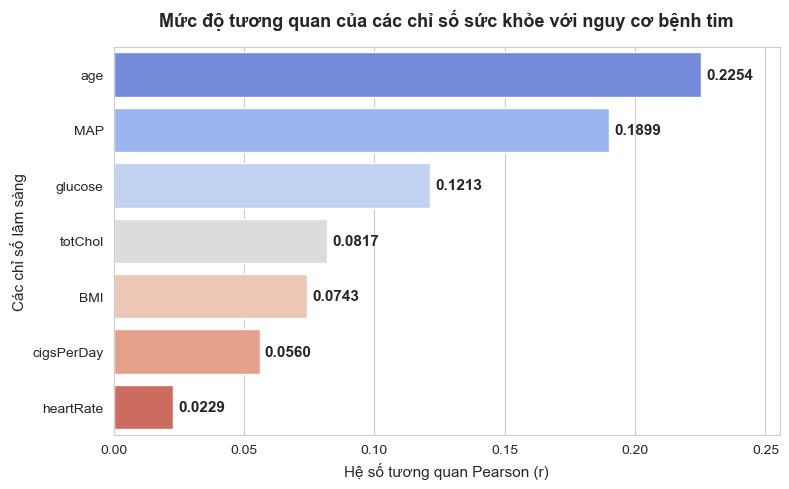

In [10]:
features_to_analyze = ['age', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose', 'MAP', 'TenYearCHD']
correlation_matrix = df[features_to_analyze].corr()

# Trích xuất dải hệ số tương quan sắp xếp giảm dần về độ lớn
target_corr = correlation_matrix['TenYearCHD'].drop('TenYearCHD').sort_values(ascending=False)
target_corr_df = target_corr.reset_index(name='Hệ số tương quan (r)')
target_corr_df.columns = ['Chỉ số sức khỏe', 'Hệ số tương quan (r)']

print("--- BẢNG HỆ SỐ TƯƠNG QUAN PEARSON VỚI BIẾN MỤC TIÊU ---")
display(target_corr_df)

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.barplot(data=target_corr_df, x='Hệ số tương quan (r)', y='Chỉ số sức khỏe', 
                 hue='Chỉ số sức khỏe', palette='coolwarm', legend=False)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.4f}", (width + 0.002, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Mức độ tương quan của các chỉ số sức khỏe với nguy cơ bệnh tim', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hệ số tương quan Pearson (r)', fontsize=11)
plt.ylabel('Các chỉ số lâm sàng', fontsize=11)
plt.xlim(0, target_corr_df['Hệ số tương quan (r)'].max() + 0.03)
plt.tight_layout()
plt.show()

### Câu hỏi 4: Tỷ lệ người thực sự có rủi ro mắc bệnh tim trong toàn bộ bộ dữ liệu là bao nhiêu phần trăm?
Ô code này tính toán chỉ số phân phối vĩ mô của biến mục tiêu `TenYearCHD` trên toàn bộ quy mô 4.240 bản ghi lâm sàng của bộ dữ liệu Framingham nhằm kiểm tra hiện tượng mất cân bằng dữ liệu và vẽ đồ thị hình tròn trực quan hóa.

SỐ LIỆU THỰC TẾ: CÓ 644 CA NGUY CƠ TRÊN TỔNG SỐ 4240 BỆNH NHÂN.
TỶ LỆ CA CÓ NGUY CƠ MẮC BỆNH TIM TỔNG THỂ TRONG BỘ DỮ LIỆU: 15.19%


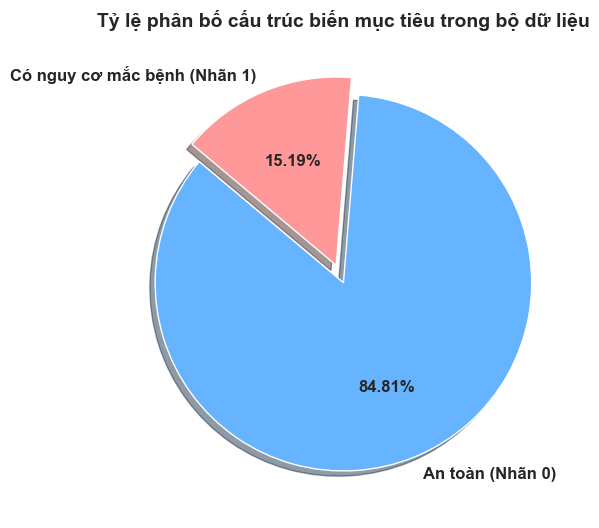

In [11]:
# 1. Tính toán tần suất và tỷ lệ % cấu trúc tổng thể
class_counts = df['TenYearCHD'].value_counts()
overall_risk_rate = df['TenYearCHD'].mean() * 100

print("="*65)
print(f"SỐ LIỆU THỰC TẾ: CÓ {class_counts[1]} CA NGUY CƠ TRÊN TỔNG SỐ {len(df)} BỆNH NHÂN.")
print(f"TỶ LỆ CA CÓ NGUY CƠ MẮC BỆNH TIM TỔNG THỂ TRONG BỘ DỮ LIỆU: {overall_risk_rate:.2f}%")
print("="*65)

# 2. Trực quan hóa bằng Biểu đồ tròn cấu trúc (Pie Chart)
plt.figure(figsize=(6, 6))
labels_pie = ['An toàn (Nhãn 0)', 'Có nguy cơ mắc bệnh (Nhãn 1)']
colors_pie = ['#66b3ff', '#ff9999']
explode_pie = (0, 0.1)  # Tách nhẹ miếng bánh nhóm thiểu số nguy cơ cao

plt.pie(class_counts, explode=explode_pie, labels=labels_pie, colors=colors_pie,
        autopct='%1.2f%%', shadow=True, startangle=140, 
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Tỷ lệ phân bố cấu trúc biến mục tiêu trong bộ dữ liệu', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Câu hỏi 5: Có thể chẩn đoán/dự đoán nguy cơ mắc bệnh tim dựa trên các chỉ số sức khỏe hay không?
Để trả lời cho câu hỏi này, nghiên cứu tiến hành thiết lập bài toán Học máy giám sát (Supervised Learning). Dữ liệu sau khi làm sạch được phân tách nghiêm ngặt thành 80% tập Train và 20% tập Test độc lập. Hệ thống sử dụng thuật toán **Random Forest Classifier** gán tham số cân bằng trọng số lớp `class_weight='balanced'` để dự đoán và xuất báo cáo đánh giá chất lượng toán học (`Accuracy`, `Classification Report`).

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Chuẩn bị ma trận đặc trưng độc lập (X) và nhãn mục tiêu (y)
X_pred = df_scaled[continuous_features]
y_pred = df['TenYearCHD'].astype(int)

# 2. Phân chia tập dữ liệu 80% Train / 20% Test phân tầng theo y
X_train, X_test, y_train, y_test = train_test_split(X_pred, y_pred, test_size=0.2, random_state=42, stratify=y_pred)

# 3. Khởi tạo mô hình Rừng ngẫu nhiên tối ưu hóa trọng số phạt lỗi
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 4. Dự đoán trên tập kiểm thử độc lập hoàn toàn
y_predictions = rf_model.predict(X_test)

# 5. In kết quả kiểm chứng toán học ra màn hình
print("="*65)
print(f"ĐỘ CHÍNH XÁC TOÀN CỤC (ACCURACY) CỦA MÔ HÌNH DỰ ĐOÁN: {accuracy_score(y_test, y_predictions)*100:.2f}%")
print("="*65)
print("BÁO CÁO CHI TIẾT CÁC CHỈ SỐ KIỂM ĐỊNH HIỆU NĂNG PHÂN LOẠI:")
print(classification_report(y_test, y_predictions))

ĐỘ CHÍNH XÁC TOÀN CỤC (ACCURACY) CỦA MÔ HÌNH DỰ ĐOÁN: 83.73%
BÁO CÁO CHI TIẾT CÁC CHỈ SỐ KIỂM ĐỊNH HIỆU NĂNG PHÂN LOẠI:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.09      0.01      0.01       129

    accuracy                           0.84       848
   macro avg       0.47      0.50      0.46       848
weighted avg       0.73      0.84      0.77       848



# XÂY DỰNG MÔ HÌNH HỌC MÁY PHÂN CỤM (K-MEANS)

### Câu hỏi 6 & 7: Đặc điểm chung của nhóm bệnh là gì và Có phân nhóm bệnh nhân thành các mức nguy cơ khác nhau được không?
Ô code này tiến hành gom cụm không giám sát (Unsupervised Learning) bằng thuật toán **K-Means**. Đầu tiên, hệ thống tính toán giá trị WCSS vòng lặp từ 1 đến 10 để phục vụ vẽ đồ thị khuỷu tay xác định số cụm $K=3$ tối ưu. Sau đó, thuật toán huấn luyện cấu hình $K=3$, gán nhãn cụm ngược lại dữ liệu gốc và xuất ra **Bảng ma trận hồ sơ trung tâm (Cluster Profiles)** nguyên bản đơn vị đo y tế nhằm bóc tách đặc điểm chân dung chung của từng nhóm nguy cơ rủi ro.

In [14]:
from sklearn.cluster import KMeans

# 1. Đo lường chỉ số WCSS (Inertia) từ K=1 đến K=10 phục vụ thuật toán Elbow
X_scaled_cluster = df_scaled[continuous_features]
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled_cluster)
    wcss.append(km.inertia_)

# 2. Thực thi phân cụm tối ưu với cấu hình chiến lược K = 3 cụm rủi ro lũy tiến
kmeans_optimal = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_optimal.fit_predict(X_scaled_cluster)

# 3. Tính toán giá trị trung bình thực tế nguyên bản của từng chỉ số lâm sàng theo từng cụm
cluster_profiles = df.groupby('Cluster').agg({
    'age': 'mean',
    'cigsPerDay': 'mean',
    'totChol': 'mean',
    'BMI': 'mean',
    'glucose': 'mean',
    'MAP': 'mean',
    'TenYearCHD': 'mean'
}).round(2)

# Đổi biến nhãn mục tiêu thành dải tỷ lệ phần trăm % dịch tễ học thực tế
cluster_profiles['TenYearCHD'] = (cluster_profiles['TenYearCHD'] * 100).round(2)
cluster_profiles = cluster_profiles.rename(columns={'TenYearCHD': 'Tỷ lệ ca bệnh thực tế (%)'})

print("--- MA TRẬN HỒ SƠ CHÂN DUNG ĐẶC TRƯNG SỨC KHỎE TRUNG TÂM CÁC CỤM ---")
display(cluster_profiles)

--- MA TRẬN HỒ SƠ CHÂN DUNG ĐẶC TRƯNG SỨC KHỎE TRUNG TÂM CÁC CỤM ---


,age,cigsPerDay,totChol,BMI,glucose,MAP,Tỷ lệ ca bệnh thực tế (%)
Cluster,,,,,,,
0,44.45,5.05,211.28,23.84,77.86,90.36,7.0
1,47.26,25.47,242.65,25.68,79.35,98.21,17.0
2,55.86,2.23,256.46,27.71,86.54,108.55,22.0


## 8. TRỰC QUAN HÓA KẾT QUẢ ĐỒ THỊ PHÂN CỤM PHẦN HỌC MÁY
Hệ thống thiết lập biểu đồ kép song song: Đồ thị bên trái biểu diễn **Phương pháp đường cong khuỷu tay (Elbow Method)** chỉ rõ điểm gãy hình học tối ưu tại $K=3$. Đồ thị bên phải biểu diễn **Không gian phân tán ranh giới phân tách (Age vs. MAP)** được gán nhãn sắc nét chữ lớn nhằm trả lời trực quan trực diện cho câu hỏi phân tầng cấu trúc rủi ro sức khỏe bệnh nhân.

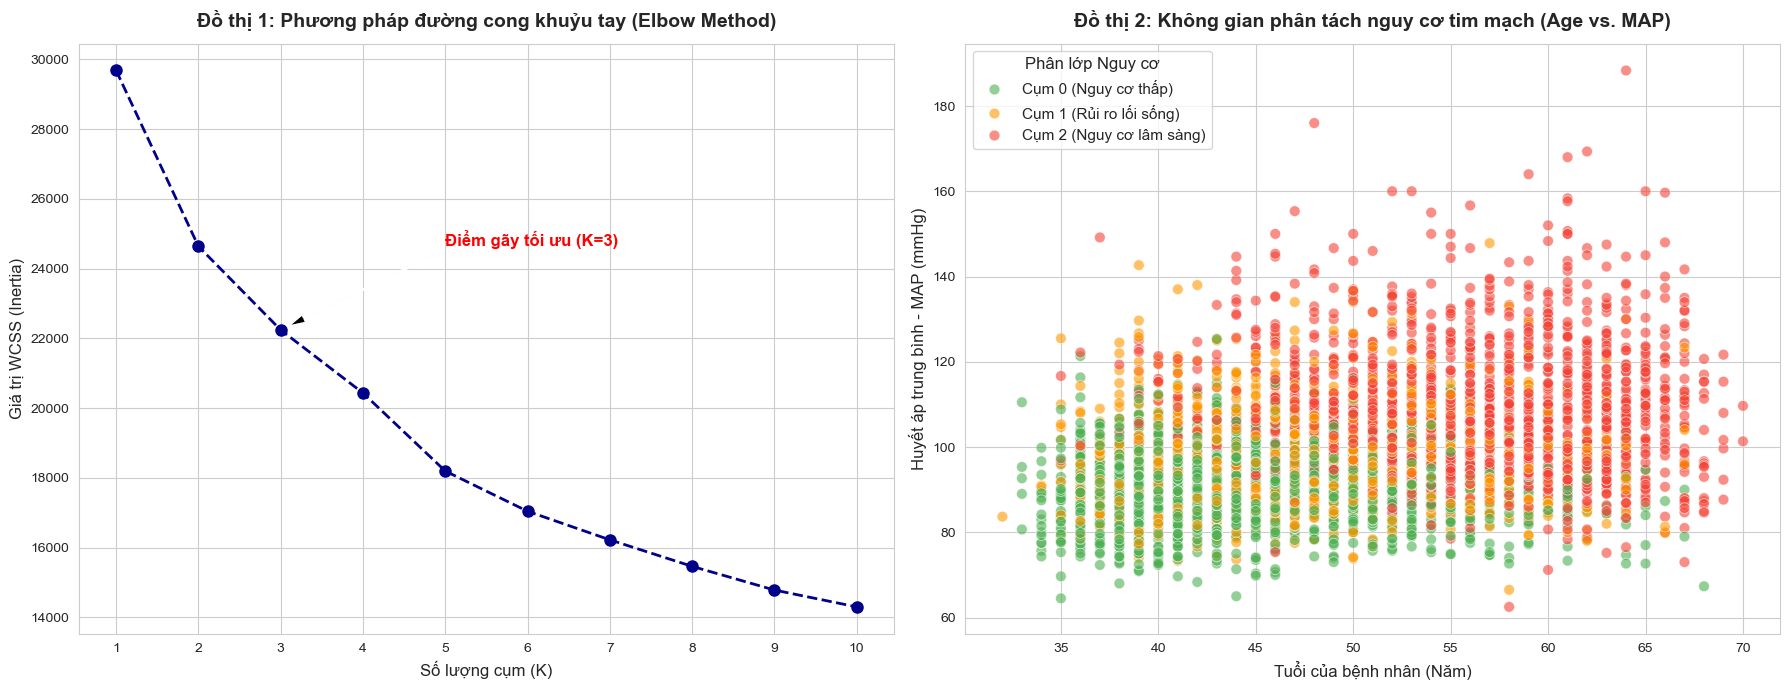

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_style("whitegrid")

# ĐỒ THỊ 1: Đường cong khuỷu tay Elbow Method chứng minh xác thực chọn K=3
axes[0].plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue', linewidth=2, markersize=8)
axes[0].set_title('Đồ thị 1: Phương pháp đường cong khuỷu tay (Elbow Method)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Số lượng cụm (K)', fontsize=12)
axes[0].set_ylabel('Giá trị WCSS (Inertia)', fontsize=12)
axes[0].set_xticks(range(1, 11))
axes[0].annotate('Điểm gãy tối ưu (K=3)', xy=(3, wcss[2]), xytext=(5, wcss[1]),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6), fontsize=12, fontweight='bold', color='red')

# ĐỒ THỊ 2: Không gian phân tán Scatter Plot biểu diễn ranh giới 3 phân lớp dải nguy cơ biệt lập
colors = ['#4caf50', '#ff9800', '#f44336'] # Xanh (Thấp), Cam (Lối sống rủi ro trẻ), Đỏ (Cao lâm sàng)
sns.scatterplot(data=df, x='age', y='MAP', hue='Cluster', palette=colors, alpha=0.6, s=60, ax=axes[1])

axes[1].set_title('Đồ thị 2: Không gian phân tách nguy cơ tim mạch (Age vs. MAP)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Tuổi của bệnh nhân (Năm)', fontsize=12)
axes[1].set_ylabel('Huyết áp trung bình - MAP (mmHg)', fontsize=12)

# Đồng bộ hóa nhãn chú thích danh mục sang tiếng Việt chuẩn mực học thuật
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Cụm 0 (Nguy cơ thấp)', 'Cụm 1 (Rủi ro lối sống)', 'Cụm 2 (Nguy cơ lâm sàng)'], 
               title='Phân lớp Nguy cơ', loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()